**Top-10 catchment attributes associated with d-HyMoLAP outperforming  HyMoLAP / GR4J / HBV — class-weighted XGBoost + Random Forest, 5-fold CV, per-fold SHAP, consensus ranking. Interpretation-focused, not predictive.**

Mounted at /content/drive
LOADING CAMELS-FR ATTRIBUTES
  Climatic                 : 654 stations x  31 features
  Topography               : 654 stations x  28 features
  Geology                  : 654 stations x  18 features
  Hydrogeology             : 654 stations x  12 features
  Land cover               : 654 stations x  17 features
  Soil                     : 5886 stations x  14 features
  Hydrology                : 654 stations x  18 features
  Hydroclimatic            : 654 stations x   9 features
  Human influences         : 654 stations x   4 features
  Station attributes       : 654 stations x  49 features
  Site attributes          : 652 stations x  36 features

✓ Merged CAMELS-FR attribute table: (654, 224)

✓ Attribute matrix (pre-preprocessing): (654, 88)
✓ Preprocessed attribute matrix: (654, 90)

✓ Performance files loaded: d-HyMoLAP=549, HyMoLAP=549, HBV=549

COMPARISON: dHyMoLAP_vs_HyMoLAP
y=1 (d-HyMoLAP >= competitor): 448 (81.6%)
y=0 (competitor better):       101

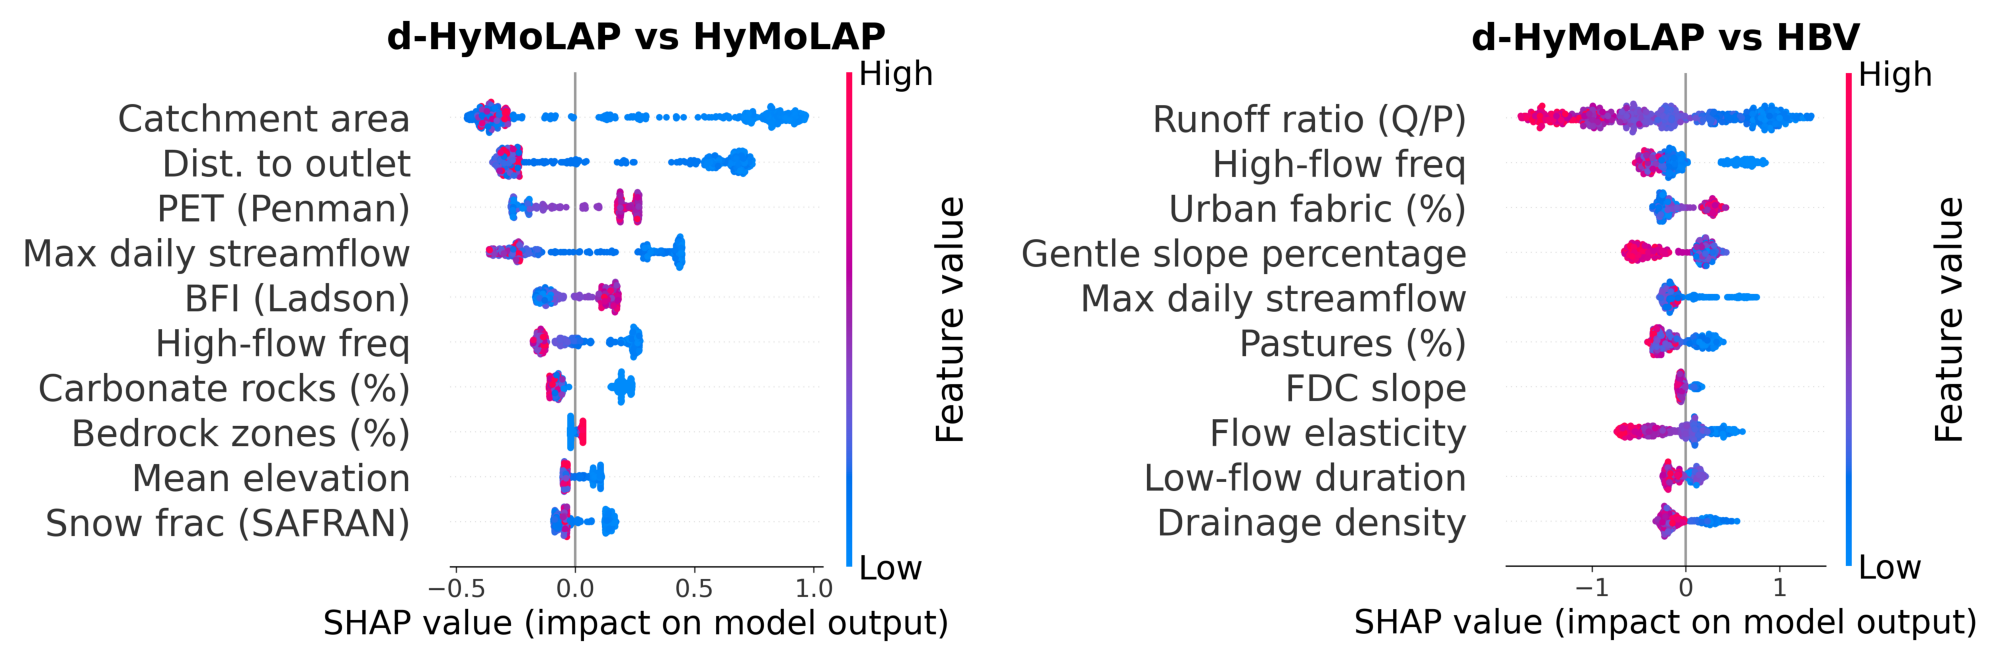


✓ Saved: SHAP_Summary_Combined_Top10.pdf
✓ Saved: SHAP_Summary_Combined_Top10.png


In [ ]:
# ============================================================================
# Top-10 catchment attributes associated with d-HyMoLAP outperforming
# HyMoLAP / HBV — class-weighted XGBoost + Random Forest, 5-fold CV,
# per-fold SHAP, consensus ranking. Interpretation-focused, not predictive.
# ============================================================================

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import io
from PIL import Image

import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (f1_score, balanced_accuracy_score,
                              average_precision_score, matthews_corrcoef)
from scipy.stats import spearmanr
import shap

from google.colab import drive
drive.mount("/content/drive")

RANDOM_SEED = 42
N_FOLDS = 5
FINAL_N = 10
COLLIN_THRESH = 1.0
np.random.seed(RANDOM_SEED)

DATA_DIR = Path("/content/drive/MyDrive/Colab Notebooks/Data")

# ============================================================================
# STEP 0A: LOAD CAMELS-FR ATTRIBUTES (same procedure as your data-prep code)
# ============================================================================
print("="*80)
print("LOADING CAMELS-FR ATTRIBUTES")
print("="*80)

attribute_files = {
    'cli': ('CAMELS_FR_climatic_statistics.csv', 'Climatic'),
    'topo': ('CAMELS_FR_topography_general_attributes.csv', 'Topography'),
    'geo': ('CAMELS_FR_geology_attributes.csv', 'Geology'),
    'hgeo': ('CAMELS_FR_hydrogeology_attributes.csv', 'Hydrogeology'),
    'lc': ('CAMELS_FR_land_cover_attributes.csv', 'Land cover'),
    'soil': ('CAMELS_FR_soil_general_attributes.csv', 'Soil'),
    'hydro': ('CAMELS_FR_hydrological_signatures.csv', 'Hydrology'),
    'hclim': ('CAMELS_FR_hydroclimatic_statistics_joint_availability_yearly.csv', 'Hydroclimatic'),
    'human': ('CAMELS_FR_human_influences_dams.csv', 'Human influences'),
    'sta': ('CAMELS_FR_station_general_attributes.csv', 'Station attributes'),
    'site': ('CAMELS_FR_site_general_attributes.csv', 'Site attributes')
}

datasets = {}
for key, (filename, desc) in attribute_files.items():
    datasets[key] = pd.read_csv(DATA_DIR / filename, sep=';')
    print(f"  {desc:25s}: {datasets[key].shape[0]:3d} stations x {datasets[key].shape[1]:3d} features")

cli, topo, geo, hgeo, lc, soil, hydro, hclim, human, sta, site = (
    datasets['cli'], datasets['topo'], datasets['geo'], datasets['hgeo'],
    datasets['lc'], datasets['soil'], datasets['hydro'], datasets['hclim'],
    datasets['human'], datasets['sta'], datasets['site']
)

numeric_soil_cols = [c for c in soil.select_dtypes(include=[np.number]).columns
                     if c != 'sta_code_h3']
soil_agg = soil.groupby('sta_code_h3')[numeric_soil_cols].mean().reset_index()

camels = cli.copy()
for df, name in [(topo, 'Topography'), (geo, 'Geology'), (hgeo, 'Hydrogeology'),
                  (lc, 'Land cover'), (soil_agg, 'Soil'), (hydro, 'Hydrology'),
                  (hclim, 'Hydroclimatic'), (human, 'Human influences'),
                  (sta, 'Station attributes'), (site, 'Site attributes')]:
    camels = camels.merge(df, on='sta_code_h3', how='left')

print(f"\n✓ Merged CAMELS-FR attribute table: {camels.shape}")

# ============================================================================
# STEP 0B: FEATURE GROUPS (same 89-attribute selection as your code)
# ============================================================================
feature_groups = {
    'Catchment_Scale': ['sta_area_snap', 'sit_area_hydro', 'sit_area_topo'],
    'Catchment_Geometry': ['top_dist_outlet_mean', 'top_drainage_density',
                           'top_mor_compact_coef', 'top_mor_elong_ratio_catchment'],
    'Precipitation_Amount': ['cli_prec_mean', 'hyc_jay_prec_mean',
                             'cli_prec_intensity', 'cli_prec_max'],
    'Precipitation_Timing': ['cli_prec_season_temp', 'cli_prec_season_pet_ou',
                             'cli_prec_freq_high', 'cli_prec_dur_high',
                             'cli_prec_freq_low', 'cli_prec_dur_low'],
    'PET_Evaporation': ['cli_pet_ou_mean', 'cli_pet_pm_mean', 'cli_pet_pe_mean'],
    'Water_Balance': ['cli_aridity_ou', 'cli_aridity_pm',
                      'hyc_jay_ratio_prec_pet_ou', 'hyc_jay_ratio_q_prec'],
    'Climate_Seasonality': ['cli_assync_ou', 'cli_assync_pm',
                            'cli_psol_frac_safran', 'cli_psol_frac_berghuijs'],
    'Temperature': ['cli_temp_mean'],
    'Baseflow_Storage': ['hyd_bfi_ladson', 'hyd_bfi_lfstat', 'hyd_bfi_pelletier_pet_ou'],
    'Flow_Magnitude': ['hyd_q_mean', 'hyd_q_max', 'hyd_q_qmna_min'],
    'Flow_Variability': ['hyd_slope_fdc', 'hyd_stream_elas', 'hyd_hfd_mean'],
    'Flow_Extremes_High': ['hyd_q_freq_high', 'hyd_q_dur_high'],
    'Flow_Extremes_Low': ['hyd_q_freq_low', 'hyd_q_dur_low', 'hyd_q_freq_zero'],
    'Topography_Elevation': ['top_altitude_mean'],
    'Topography_Slope': ['top_slo_mean', 'top_slo_gentle', 'top_slo_steep', 'top_slo_very_steep'],
    'Topography_Morphology': ['top_mor_relief_ratio', 'top_mor_shape_factor', 'top_mor_circ_ratio'],
    'Topography_Aspect': ['top_slo_ori_n', 'top_slo_ori_s'],
    'Geology_Lithology': ['geo_dom_class', 'geo_su', 'geo_sc', 'geo_ss', 'geo_mt'],
    'Hydrogeology_Aquifer': ['hgl_permeability', 'hgl_porosity', 'hgl_krs_karstic',
                            'hgl_thm_alluvial', 'hgl_thm_bedrock'],
    'Soil_Texture': ['sol_clay', 'sol_sand', 'sol_silt'],
    'Soil_Properties': ['sol_depth_to_root', 'sol_depth_to_bedrock', 'sol_tawc',
                        'sol_conductivity', 'sol_bd', 'sol_gravel'],
    'Landcover_Dominant': ['clc_2018_lvl2_dom_class'],
    'Landcover_Urban': ['clc_2018_lvl2_11', 'clc_2018_lvl2_12'],
    'Landcover_Agriculture': ['clc_2018_lvl2_21', 'clc_2018_lvl2_22',
                             'clc_2018_lvl2_23', 'clc_2018_lvl2_24'],
    'Landcover_Forest': ['clc_2018_lvl2_31', 'clc_2018_lvl2_32', 'clc_2018_lvl2_33'],
    'Landcover_Wetland_Water': ['clc_2018_lvl2_41', 'clc_2018_lvl2_51'],
    'Human_Regulation': ['dam_n', 'dam_volume', 'dam_influence'],
}

all_group_features = [f for feats in feature_groups.values() for f in feats]
available_features = [f for f in all_group_features if f in camels.columns]
missing_features = [f for f in all_group_features if f not in camels.columns]
if missing_features:
    print(f"\n⚠ Missing from attribute tables ({len(missing_features)}): {missing_features}")

X_raw = camels[['sta_code_h3'] + available_features].copy()
print(f"\n✓ Attribute matrix (pre-preprocessing): {X_raw.shape}")

# ============================================================================
# STEP 0C: PREPROCESSING (impute, encode, drop near-constant / quasi-duplicates)
# ============================================================================
def preprocess_features(df):
    df = df.copy()
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
    if categorical_cols:
        df[categorical_cols] = df[categorical_cols].fillna('Unknown')

    if 'sta_x_w84' in df.columns and 'sta_y_w84' in df.columns:
        df['lon_norm'] = (df['sta_x_w84'] - df['sta_x_w84'].mean()) / df['sta_x_w84'].std()
        df['lat_norm'] = (df['sta_y_w84'] - df['sta_y_w84'].mean()) / df['sta_y_w84'].std()
        df = df.drop(columns=['sta_x_w84', 'sta_y_w84'])

    categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    if categorical_cols:
        df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

    variances = df.var(numeric_only=True)
    low_var = variances[variances <= 1e-4].index.tolist()
    df = df.drop(columns=low_var)

    corr = df.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    dup_drop = [c for c in upper.columns if any(upper[c] > 0.98)]
    df = df.drop(columns=dup_drop)

    return df

X_id = X_raw['sta_code_h3']
X_processed = preprocess_features(X_raw.drop(columns=['sta_code_h3']))
X_processed.insert(0, 'sta_code_h3', X_id)

print(f"✓ Preprocessed attribute matrix: {X_processed.shape}")

# ============================================================================
# STEP 1: LOAD PERFORMANCE FILES
# ============================================================================
def load_performance(filename, label):
    df = pd.read_csv(DATA_DIR / filename)
    df = df[['station_id', 'NSE_val']].rename(columns={'NSE_val': f'NSE_{label}'})
    return df

perf_dhymolap = load_performance('dHyMoLAP_Simulation_Data_CAMELS_FR.csv', 'dHyMoLAP')
perf_hymolap  = load_performance('HyMoLAP_Simulation_Data_CAMELS_FR.csv', 'HyMoLAP')
perf_hbv      = load_performance('HBV_Simulation_Data_CAMELS_FR.csv', 'HBV')

print(f"\n✓ Performance files loaded: "
      f"d-HyMoLAP={len(perf_dhymolap)}, HyMoLAP={len(perf_hymolap)}, "
      f"HBV={len(perf_hbv)}")

# ============================================================================
# STEP 2: SPEARMAN COLLINEARITY FILTER (target-aware tie-break) (via COLLIN_THRESH)
# ============================================================================
def spearman_collinearity_filter(X, y, threshold=COLLIN_THRESH):
    feats = X.columns.tolist()
    target_assoc = {f: abs(spearmanr(X[f], y).correlation) for f in feats}

    corr = X.corr(method='spearman').abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    to_drop = set()
    for col in upper.columns:
        for row in upper.index:
            if pd.isna(upper.loc[row, col]):
                continue
            if upper.loc[row, col] > threshold:
                weaker = row if target_assoc.get(row, 0) < target_assoc.get(col, 0) else col
                to_drop.add(weaker)

    kept = [f for f in feats if f not in to_drop]
    return X[kept], sorted(to_drop)

# ============================================================================
# STEP 3-8: MODELING + PER-FOLD SHAP + CONSENSUS RANKING
# ============================================================================
rf_params_base = dict(n_estimators=1000, max_depth=6, min_samples_leaf=10,
                      max_features='sqrt', class_weight='balanced',
                      random_state=RANDOM_SEED, n_jobs=-1)

xgb_params_base = dict(n_estimators=1000, max_depth=6, learning_rate=0.01,
                       subsample=0.8, colsample_bytree=0.8, min_child_weight=10,
                       gamma=1.0, reg_lambda=1.5, reg_alpha=0.5,
                       objective='binary:logistic', eval_metric='logloss',
                       random_state=RANDOM_SEED, n_jobs=-1, verbosity=0)

def run_comparison(comparison_name, X, y):
    print("\n" + "="*80)
    print(f"COMPARISON: {comparison_name}")
    print("="*80)
    print(f"y=1 (d-HyMoLAP >= competitor): {sum(y==1)} ({100*sum(y==1)/len(y):.1f}%)")
    print(f"y=0 (competitor better):       {sum(y==0)} ({100*sum(y==0)/len(y):.1f}%)")

    X_filt, dropped = spearman_collinearity_filter(X, y)
    print(f"Collinearity filter (|rho|>{COLLIN_THRESH}): dropped {len(dropped)} features "
          f"-> {X_filt.shape[1]} remain")

    cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

    rf_shap_folds, xgb_shap_folds = [], []
    rf_metrics, xgb_metrics = [], []

    for fold_idx, (tr_idx, val_idx) in enumerate(cv.split(X_filt, y), 1):
        X_tr, X_val = X_filt.iloc[tr_idx], X_filt.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        # --- Random Forest ---
        rf = RandomForestClassifier(**rf_params_base)
        rf.fit(X_tr, y_tr)
        y_pred = rf.predict(X_val)
        y_prob = rf.predict_proba(X_val)[:, 1]
        rf_metrics.append({
            'fold': fold_idx,
            'mcc': matthews_corrcoef(y_val, y_pred),
            'pr_auc': average_precision_score(y_val, y_prob),
            'bal_acc': balanced_accuracy_score(y_val, y_pred),
            'f1_minority': f1_score(y_val, y_pred, pos_label=1, average='binary',
                                    zero_division=0),
            'f1_weighted': f1_score(y_val, y_pred, average='weighted')
        })
        sv_raw = shap.TreeExplainer(rf).shap_values(X_val)
        if isinstance(sv_raw, list):
            sv1 = sv_raw[1]
        elif isinstance(sv_raw, np.ndarray) and sv_raw.ndim == 3:
            sv1 = sv_raw[:, :, 1]
        else:
            sv1 = sv_raw
        rf_shap_folds.append(np.abs(sv1).mean(axis=0))

        # --- XGBoost (scale_pos_weight computed per fold) ---
        n_pos, n_neg = sum(y_tr == 1), sum(y_tr == 0)
        spw = n_neg / n_pos if n_pos > 0 else 1.0
        xgbc = xgb.XGBClassifier(**xgb_params_base, scale_pos_weight=spw)
        xgbc.fit(X_tr, y_tr)
        y_pred = xgbc.predict(X_val)
        y_prob = xgbc.predict_proba(X_val)[:, 1]
        xgb_metrics.append({
            'fold': fold_idx,
            'mcc': matthews_corrcoef(y_val, y_pred),
            'pr_auc': average_precision_score(y_val, y_prob),
            'bal_acc': balanced_accuracy_score(y_val, y_pred),
            'f1_minority': f1_score(y_val, y_pred, pos_label=1, average='binary',
                                    zero_division=0),
            'f1_weighted': f1_score(y_val, y_pred, average='weighted')
        })
        sv = shap.TreeExplainer(xgbc).shap_values(X_val)
        xgb_shap_folds.append(np.abs(sv).mean(axis=0))

    rf_perf = pd.DataFrame(rf_metrics)
    xgb_perf = pd.DataFrame(xgb_metrics)

    summary_table = pd.DataFrame({
        'Model': ['Random Forest', 'XGBoost'],
        'MCC': [rf_perf['mcc'].mean(), xgb_perf['mcc'].mean()],
        'MCC_std': [rf_perf['mcc'].std(), xgb_perf['mcc'].std()],
        'PR_AUC': [rf_perf['pr_auc'].mean(), xgb_perf['pr_auc'].mean()],
        'PR_AUC_std': [rf_perf['pr_auc'].std(), xgb_perf['pr_auc'].std()],
        'Balanced_Accuracy': [rf_perf['bal_acc'].mean(), xgb_perf['bal_acc'].mean()],
        'Balanced_Accuracy_std': [rf_perf['bal_acc'].std(), xgb_perf['bal_acc'].std()],
        'Minority_F1': [rf_perf['f1_minority'].mean(), xgb_perf['f1_minority'].mean()],
        'Minority_F1_std': [rf_perf['f1_minority'].std(), xgb_perf['f1_minority'].std()],
        'Weighted_F1': [rf_perf['f1_weighted'].mean(), xgb_perf['f1_weighted'].mean()],
        'Weighted_F1_std': [rf_perf['f1_weighted'].std(), xgb_perf['f1_weighted'].std()],
    })

    print(f"\nCross-validated performance ({N_FOLDS}-fold, mean ± std):")
    print(summary_table.to_string(index=False,
          formatters={c: (lambda v: f"{v:.3f}") for c in summary_table.columns
                      if c != 'Model'}))

    summary_table.to_csv(f'Metrics_{comparison_name.replace(" ", "_")}.csv', index=False)

    rf_mean = np.vstack(rf_shap_folds).mean(axis=0)
    xgb_mean = np.vstack(xgb_shap_folds).mean(axis=0)

    def norm(v):
        rng = v.max() - v.min()
        return (v - v.min()) / rng if rng > 0 else np.zeros_like(v)

    consensus = pd.DataFrame({
        'Feature': X_filt.columns,
        'RF_SHAP_mean': rf_mean,
        'XGB_SHAP_mean': xgb_mean,
        'RF_norm': norm(rf_mean),
        'XGB_norm': norm(xgb_mean)
    })
    consensus['Consensus_score'] = (consensus['RF_norm'] + consensus['XGB_norm']) / 2
    consensus = consensus.sort_values('Consensus_score', ascending=False).reset_index(drop=True)

    top10 = consensus.head(FINAL_N)
    print(f"\nTop {FINAL_N} consensus features:")
    print(top10[['Feature', 'RF_SHAP_mean', 'XGB_SHAP_mean', 'Consensus_score']]
          .to_string(index=False))

    consensus.to_csv(f'Consensus_{comparison_name.replace(" ", "_")}.csv', index=False)

    n_pos, n_neg = sum(y == 1), sum(y == 0)
    spw_full = n_neg / n_pos if n_pos > 0 else 1.0
    xgb_final = xgb.XGBClassifier(**xgb_params_base, scale_pos_weight=spw_full)
    xgb_final.fit(X_filt, y)
    shap_full = shap.TreeExplainer(xgb_final).shap_values(X_filt)

    top10_features = top10['Feature'].tolist()
    col_idx = [X_filt.columns.get_loc(f) for f in top10_features]
    shap_top10 = shap_full[:, col_idx]
    X_top10 = X_filt.iloc[:, col_idx]

    return consensus, summary_table, top10_features, shap_top10, X_top10

# ============================================================================
# STEP 9: RUN THE TWO COMPARISONS
# ============================================================================
comparisons = [
    ("dHyMoLAP_vs_HyMoLAP", perf_hymolap, "HyMoLAP", "d-HyMoLAP vs HyMoLAP"),
    ("dHyMoLAP_vs_HBV",     perf_hbv,     "HBV",     "d-HyMoLAP vs HBV"),
]

all_results = {}
panel_data = []

for comp_name, perf_competitor, competitor_label, panel_title in comparisons:
    merged = perf_dhymolap.merge(perf_competitor, on='station_id', how='inner')
    merged = merged.merge(X_processed, left_on='station_id', right_on='sta_code_h3',
                          how='inner').drop(columns=['sta_code_h3'])

    y = (merged['NSE_dHyMoLAP'] >= merged[f'NSE_{competitor_label}']).astype(int)
    X_features = merged.drop(columns=['station_id', 'NSE_dHyMoLAP',
                                       f'NSE_{competitor_label}'])

    consensus, summary_table, top10_features, shap_top10, X_top10 = \
        run_comparison(comp_name, X_features, y)

    all_results[comp_name] = (consensus, summary_table)
    panel_data.append((panel_title, top10_features, shap_top10, X_top10))

print("\n" + "="*80)
print("✅ BOTH COMPARISONS COMPLETE")
print("="*80)

# ============================================================================
# FEATURE NAME MAPPING
# Derived from official CAMELS-FR attribute descriptions (uploaded metadata file)
# ============================================================================
FEATURE_NAME_MAPPING = {
    'hyd_q_freq_high':      'High-flow freq',
    'hyd_q_max':            'Max daily streamflow',
    'hyd_bfi_ladson':       'BFI (Ladson)',
    'hyd_slope_fdc':        'FDC slope',
    'hyd_q_dur_high':       'High-flow duration',
    'hyd_hfd_mean':         'Half-flow date',
    'hyd_stream_elas':      'Flow elasticity',
    'hyd_q_freq_low':       'Low-flow freq',
    'hyd_q_dur_low':        'Low-flow duration',
    'hyc_jay_ratio_q_prec': 'Runoff ratio (Q/P)',
    'cli_pet_pe_mean':      'PET (Penman)',
    'cli_psol_frac_safran': 'Snow frac (SAFRAN)',
    'top_dist_outlet_mean': 'Dist. to outlet',
    'top_altitude_mean':    'Mean elevation',
    'top_drainage_density': 'Drainage density',
    'geo_sc':               'Carbonate rocks (%)',
    'hgl_thm_bedrock':      'Bedrock zones (%)',
    'clc_2018_lvl2_23':     'Pastures (%)',
    'clc_2018_lvl2_11':     'Urban fabric (%)',
    'sta_area_snap':        'Catchment area',
    'top_slo_gentle':       'Gentle slope percentage',
}

# ============================================================================
# COMBINED PUBLICATION-QUALITY SHAP BEESWARM FIGURE (1 x 2)
# ============================================================================
FONT_TITLE        = 22
FONT_AXIS_LABEL   = 20
FONT_FEATURE_NAMES = 22
FONT_TICK         = 15
FONT_CBAR_LABEL   = 22
FONT_CBAR_TICKS   = 20

panel_images = []

for title, top10_features, shap_vals, X_vals in panel_data:
    fig_i = plt.figure(figsize=(10, 10))

    display_names = [FEATURE_NAME_MAPPING.get(f, f) for f in top10_features]

    shap.summary_plot(
        shap_vals,
        X_vals,
        feature_names=display_names,
        plot_type='dot',
        sort=False,
        show=False,
        max_display=FINAL_N,
        color_bar=True
    )

    ax_i = plt.gca()
    ax_i.set_title(title, fontsize=FONT_TITLE, fontweight='bold', pad=14)
    ax_i.set_xlabel('SHAP value (impact on model output)', fontsize=FONT_AXIS_LABEL)
    ax_i.tick_params(axis='x', labelsize=FONT_TICK)
    ax_i.tick_params(axis='y', labelsize=FONT_FEATURE_NAMES)

    for extra_ax in fig_i.axes:
        if extra_ax is not ax_i:
            extra_ax.tick_params(labelsize=FONT_CBAR_TICKS)
            extra_ax.set_ylabel(extra_ax.get_ylabel(), fontsize=FONT_CBAR_LABEL)

    fig_i.tight_layout()

    buf = io.BytesIO()
    fig_i.savefig(buf, format='png', dpi=300, bbox_inches='tight')
    buf.seek(0)
    panel_images.append(Image.open(buf).copy())
    buf.close()
    plt.close(fig_i)

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
for ax, img in zip(axes, panel_images):
    ax.imshow(img)
    ax.axis('off')

plt.tight_layout(w_pad=2.0)
plt.savefig('SHAP_Summary_Combined_Top10.pdf', dpi=300, bbox_inches='tight')
plt.savefig('SHAP_Summary_Combined_Top10.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: SHAP_Summary_Combined_Top10.pdf")
print("✓ Saved: SHAP_Summary_Combined_Top10.png")